# Notebook 2 — Entraînement et évaluation du modèle Naive Bayes


## Objectif
L’objectif de ce notebook est d’entraîner un modèle de classification supervisée capable de prédire le genre principal d’un film à partir des variables numériques préparées dans le notebook précédent.

Trois modèles sont étudiés :
- un modèle principal : **Gaussian Naive Bayes**, 
- un modèle de comparaison : **Random Forest**.
- un autre modèle de comparaison : **Gradient Boosting**.

## Démarche
La démarche adoptée est la suivante :
1. chargement de la donnée préparée ;
2. vérification de la cohérence du dataset final ;
3. séparation des variables explicatives et de la cible ;
4. découpage en ensembles d’entraînement et de test ;
5. entraînement du modèle Naive Bayes ;
6. évaluation détaillée ;
7. entraînement d’un second et d'un troisième modèle de référence ;
8. comparaison rigoureuse des performances ;
9. analyse critique des résultats.

## Variables utilisées
- `year`
- `rating`
- `duration`
- `votes_log`
- `gross_income_log`
- `certificate_encoded`

Variable cible :
- `genre_encoded`


In [ ]:
from pathlib import Path
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
import numpy as np
import json
import joblib
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## 1. Définition des chemins

In [106]:
#Racine projet
PROJECT_ROOT = Path.cwd().resolve().parent
PROCESSED_PATH = PROJECT_ROOT / "data" / "processed" / "movies_clean.csv"
MAPPING_PATH = PROJECT_ROOT / "data" / "processed" / "genre_label_mapping.csv"
#Dossiers
MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"
#création si non existants
MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

MODELS_DIR, REPORTS_DIR

(WindowsPath('C:/Users/KenziLali/Desktop/projet-naive-bayes-imdb/models'),
 WindowsPath('C:/Users/KenziLali/Desktop/projet-naive-bayes-imdb/reports'))

## 2. Chargement du dataset processed

In [107]:
df = pd.read_csv(PROCESSED_PATH)
label_mapping = pd.read_csv(MAPPING_PATH)

df.head()

,name,year,rating,duration,votes_log,gross_income_log,certificate_encoded,genre,genre_encoded
0,Wadd: The Life & Times of John C. Holmes,"1,999.0000",6.8000,105.0000,6.8112,0.0000,12,Documentary,1
1,The Kama Sutra of Vatsyayana,"1,993.0000",2.9000,60.0000,3.2581,0.0000,33,Documentary,1
2,Die Rückkehr der Gabelstaplerfahrer,"2,013.0000",2.2000,35.0000,4.4308,0.0000,13,Short,3
3,Jimihen!! Jimiko o Kae Chau Jun Isei Kouyuu,"2,021.0000",7.1000,3.0000,4.0254,0.0000,13,Animation,0
4,Minions: The Rise of Gru,"2,022.0000",7.3000,87.0000,7.1074,18.7205,16,Animation,0


In [108]:
label_mapping

,genre,genre_encoded
0,Animation,0
1,Documentary,1
2,Music,2
3,Short,3


In [109]:
print(f"Dimensions du dataset : {df.shape[0]} lignes × {df.shape[1]} colonnes")

Dimensions du dataset : 443035 lignes × 9 colonnes


In [110]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 443035 entries, 0 to 443034
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   name                 443034 non-null  object 
 1   year                 443035 non-null  float64
 2   rating               443035 non-null  float64
 3   duration             443035 non-null  float64
 4   votes_log            443035 non-null  float64
 5   gross_income_log     443035 non-null  float64
 6   certificate_encoded  443035 non-null  int64  
 7   genre                443035 non-null  object 
 8   genre_encoded        443035 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 30.4+ MB


In [111]:
df.isna().sum().to_frame("nb_valeurs_manquantes")

,nb_valeurs_manquantes
name,1
year,0
rating,0
duration,0
votes_log,0
gross_income_log,0
certificate_encoded,0
genre,0
genre_encoded,0


In [112]:
df["genre"].value_counts()

genre
Short          171723
Animation      122514
Music           77306
Documentary     71492
Name: count, dtype: int64

## 3. Définition des variables explicatives et de la cible


La variable cible est `genre_encoded`, issue de l’encodage du genre principal du film.


In [113]:
feature_columns = [
    "year",
    "rating",
    "duration",
    "votes_log",
    "gross_income_log",
    "certificate_encoded"
]
target_column = "genre_encoded"

X = df[feature_columns]
y = df["genre_encoded"]

X.head()

,year,rating,duration,votes_log,gross_income_log,certificate_encoded
0,"1,999.0000",6.8000,105.0000,6.8112,0.0000,12
1,"1,993.0000",2.9000,60.0000,3.2581,0.0000,33
2,"2,013.0000",2.2000,35.0000,4.4308,0.0000,13
3,"2,021.0000",7.1000,3.0000,4.0254,0.0000,13
4,"2,022.0000",7.3000,87.0000,7.1074,18.7205,16


In [114]:
y.head()

0    1
1    1
2    3
3    0
4    0
Name: genre_encoded, dtype: int64

## 4. Séparation en jeu d'entraînement et jeu de test

On utilise ici un découpage :
- **80 %** pour l'entraînement ;
- **20 %** pour le test.

Le paramètre `stratify=y` permet de conserver une répartition cohérente des classes entre apprentissage et test.

In [115]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Dimensions X_train :", X_train.shape)
print("Dimensions X_test  :", X_test.shape)
print("Dimensions y_train :", y_train.shape)
print("Dimensions y_test  :", y_test.shape)

Dimensions X_train : (354428, 6)
Dimensions X_test  : (88607, 6)
Dimensions y_train : (354428,)
Dimensions y_test  : (88607,)


#### Standardisation 

In [116]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 5. Entraînement du Modèle 1 — Gaussian Naive Bayes



### 5.1 Entraînement

In [117]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

GaussianNB()

### 5.2 Prédictions

In [118]:
y_pred_nb = nb_model.predict(X_test)

### 5.3 Evaluation globale

In [119]:
nb_accuracy = accuracy_score(y_test, y_pred_nb)
nb_precision = precision_score(y_test, y_pred_nb, average="macro", zero_division=0)
nb_recall = recall_score(y_test, y_pred_nb, average="macro", zero_division=0)
nb_f1 = f1_score(y_test, y_pred_nb, average="macro", zero_division=0)

print("Naive Bayes")
print(f"Accuracy        : {nb_accuracy:.4f}")
print(f"Precision macro : {nb_precision:.4f}")
print(f"Recall macro    : {nb_recall:.4f}")
print(f"F1-score macro  : {nb_f1:.4f}")

Naive Bayes
Accuracy        : 0.5535
Precision macro : 0.5218
Recall macro    : 0.4381
F1-score macro  : 0.4317


### 5.4 Rapport de classification détaillé

In [120]:
target_names = label_mapping.sort_values("genre_encoded")["genre"].tolist()

print(classification_report(
    y_test,
    y_pred_nb,
    target_names=target_names,
    zero_division=0
))

              precision    recall  f1-score   support

   Animation       0.72      0.55      0.62     24503
 Documentary       0.58      0.16      0.25     14298
       Music       0.24      0.14      0.17     15461
       Short       0.55      0.91      0.68     34345

    accuracy                           0.55     88607
   macro avg       0.52      0.44      0.43     88607
weighted avg       0.55      0.55      0.51     88607



### 5.5 Matrice de confusion

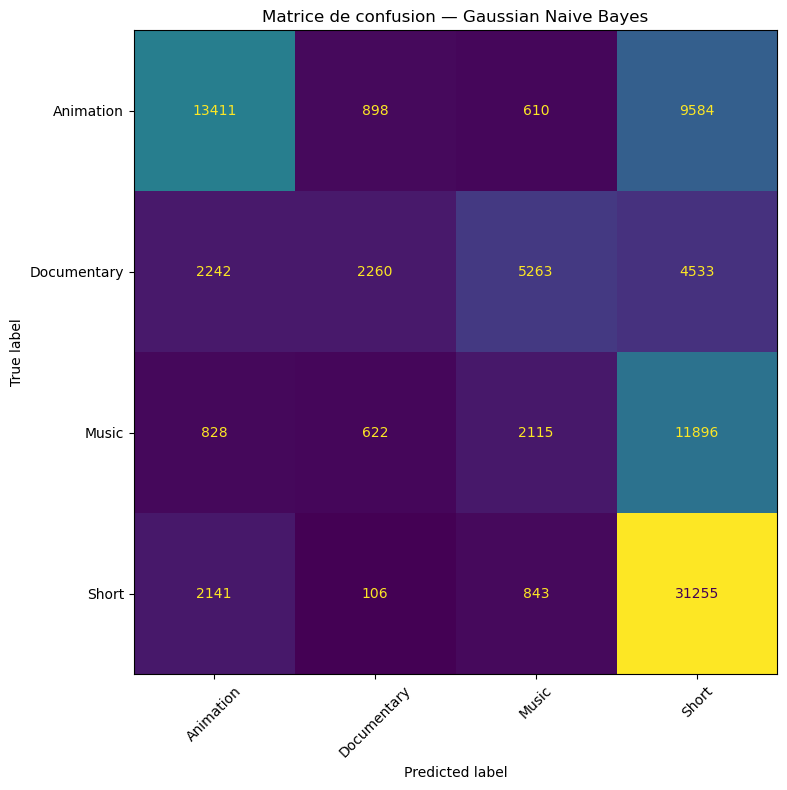

In [121]:
cm_nb = confusion_matrix(y_test, y_pred_nb)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=target_names)
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Matrice de confusion — Gaussian Naive Bayes")
plt.tight_layout()
plt.show()

## 6. Entraînement du Modèle 2 — Random Forest



### 6.1 Entraînement

In [122]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=20,
                       min_samples_leaf=5, min_samples_split=10,
                       n_estimators=300, n_jobs=-1, random_state=42)

### 6.2 Prédictions

In [123]:
y_pred_rf = rf_model.predict(X_test)

### 6.3 Evaluation globale

In [124]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf, average="macro", zero_division=0)
rf_recall = recall_score(y_test, y_pred_rf, average="macro", zero_division=0)
rf_f1 = f1_score(y_test, y_pred_rf, average="macro", zero_division=0)

print("Random Forest")
print(f"Accuracy        : {rf_accuracy:.4f}")
print(f"Precision macro : {rf_precision:.4f}")
print(f"Recall macro    : {rf_recall:.4f}")
print(f"F1-score macro  : {rf_f1:.4f}")

Random Forest
Accuracy        : 0.7013
Precision macro : 0.6991
Recall macro    : 0.7068
F1-score macro  : 0.6938


### 6.4 Rapport de classification détaillé

In [125]:
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=target_names,
    zero_division=0
))

              precision    recall  f1-score   support

   Animation       0.84      0.65      0.74     24503
 Documentary       0.66      0.67      0.67     14298
       Music       0.55      0.80      0.65     15461
       Short       0.74      0.70      0.72     34345

    accuracy                           0.70     88607
   macro avg       0.70      0.71      0.69     88607
weighted avg       0.72      0.70      0.70     88607



### 6.5 Matrice de confusion

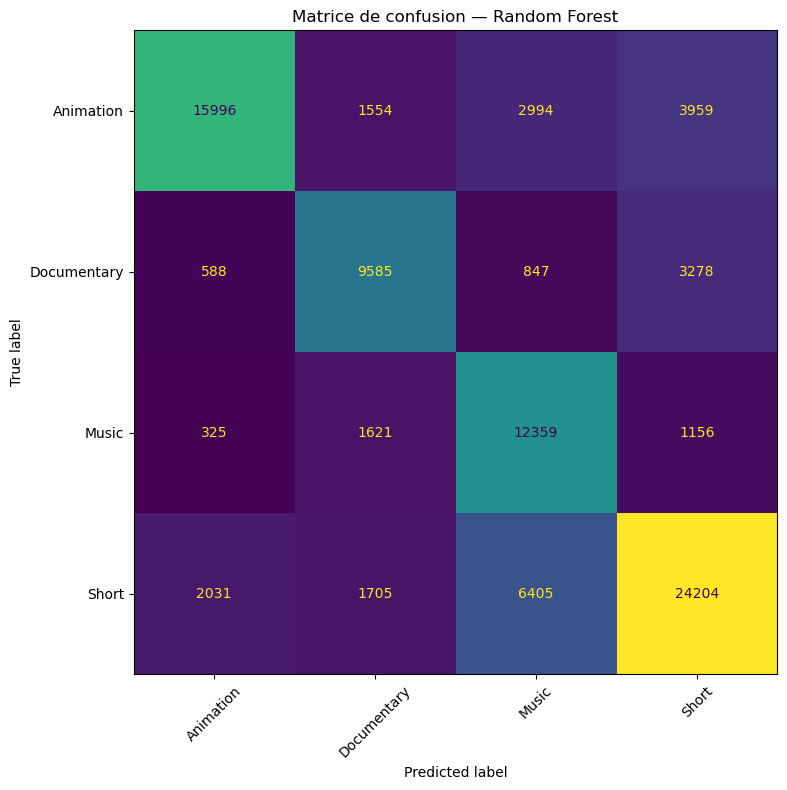

In [126]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=target_names)
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Matrice de confusion — Random Forest")
plt.tight_layout()
plt.show()

## 7. Entrainement du Modèle 3 — Gradient Boosting

### 7.1 Entrainement 

In [127]:
gb_model = HistGradientBoostingClassifier(
    max_iter=200,
    max_depth=10,
    learning_rate=0.1,
    random_state=42
)

gb_model.fit(X_train, y_train)

HistGradientBoostingClassifier(max_depth=10, max_iter=200, random_state=42)

### 7.2 Prédictions

In [128]:
y_pred_gb = gb_model.predict(X_test)

### 7.3 Evaluation

In [129]:
gb_accuracy = accuracy_score(y_test, y_pred_gb)
gb_precision = precision_score(y_test, y_pred_gb, average="macro", zero_division=0)
gb_recall = recall_score(y_test, y_pred_gb, average="macro", zero_division=0)
gb_f1 = f1_score(y_test, y_pred_gb, average="macro", zero_division=0)

print("Gradient Boosting")
print(f"Accuracy        : {gb_accuracy:.4f}")
print(f"Precision macro : {gb_precision:.4f}")
print(f"Recall macro    : {gb_recall:.4f}")
print(f"F1-score macro  : {gb_f1:.4f}")

Gradient Boosting
Accuracy        : 0.7153
Precision macro : 0.7262
Recall macro    : 0.6878
F1-score macro  : 0.6982


### 7.4 Rapport détaillé

In [130]:
print(classification_report(
    y_test,
    y_pred_gb,
    target_names=target_names,
    zero_division=0
))

              precision    recall  f1-score   support

   Animation       0.86      0.64      0.74     24503
 Documentary       0.75      0.58      0.65     14298
       Music       0.61      0.70      0.65     15461
       Short       0.69      0.83      0.75     34345

    accuracy                           0.72     88607
   macro avg       0.73      0.69      0.70     88607
weighted avg       0.73      0.72      0.71     88607



### 7.5 Matrice de confusion

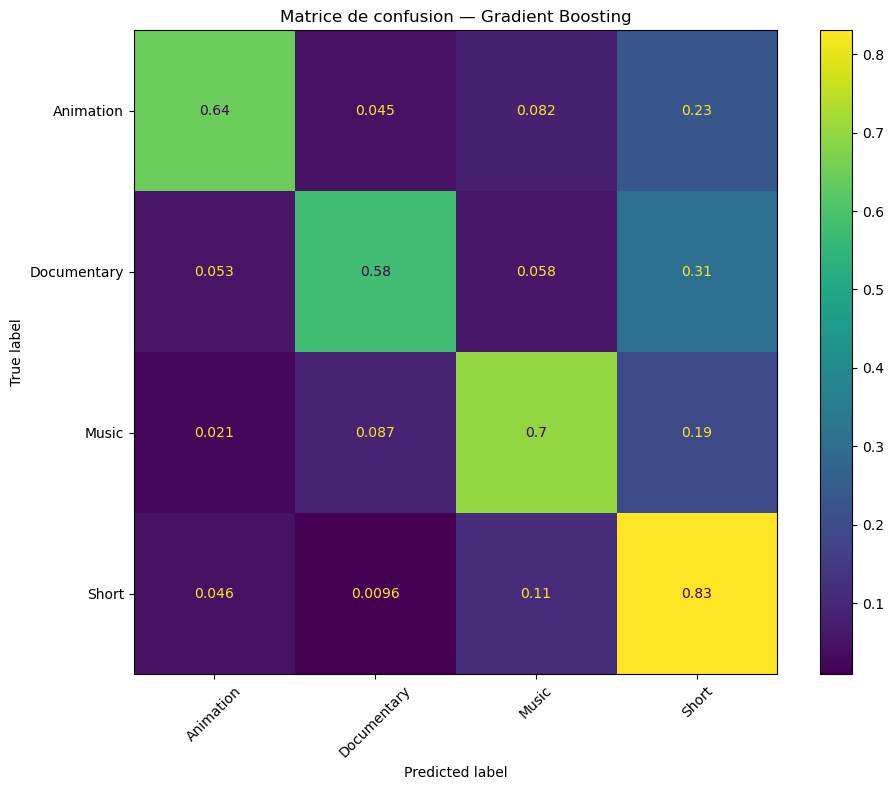

In [131]:
cm_gb = confusion_matrix(y_test, y_pred_gb, normalize="true")

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(cm_gb, display_labels=target_names)
disp.plot(ax=ax, xticks_rotation=45, cmap="viridis")
plt.title("Matrice de confusion — Gradient Boosting")
plt.tight_layout()
plt.show()

## 8. Comparaison rigoureuse des modèles


### 8.1 Tableau récapitulatif

In [132]:
comparison = pd.DataFrame({
    "Modèle": [
        "Gaussian Naive Bayes",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        nb_accuracy,
        rf_accuracy,
        gb_accuracy
    ],
    "Precision_macro": [
        nb_precision,
        rf_precision,
        gb_precision
    ],
    "Recall_macro": [
        nb_recall,
        rf_recall,
        gb_recall
    ],
    "F1_macro": [
        nb_f1,
        rf_f1,
        gb_f1
    ]
})

comparison.sort_values("F1_macro", ascending=False)

,Modèle,Accuracy,Precision_macro,Recall_macro,F1_macro
2,Gradient Boosting,0.7153,0.7262,0.6878,0.6982
1,Random Forest,0.7013,0.6991,0.7068,0.6938
0,Gaussian Naive Bayes,0.5535,0.5218,0.4381,0.4317


### 8.2 Visualisation simple

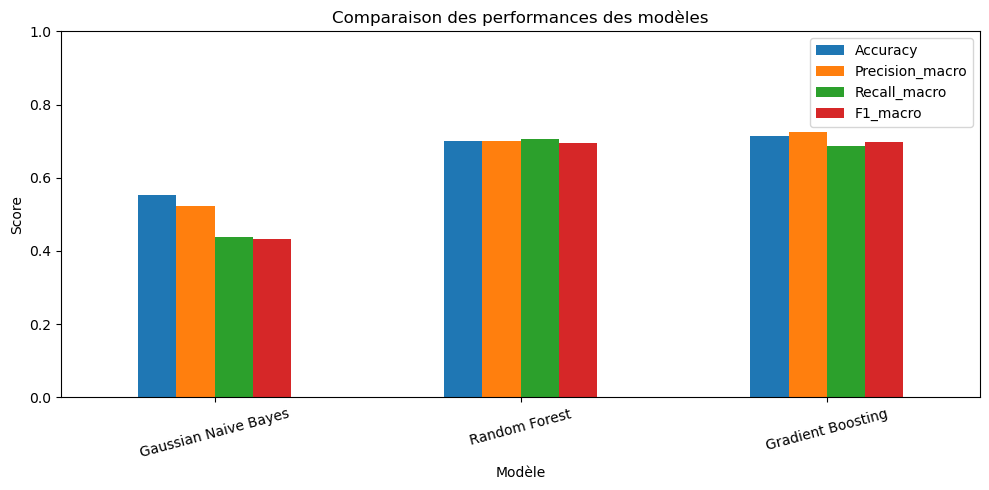

In [133]:
comparison_plot = comparison.set_index("Modèle")

comparison_plot.plot(kind="bar", figsize=(10, 5))
plt.title("Comparaison des performances des modèles")
plt.ylabel("Score")
plt.xticks(rotation=15)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## 9. Rapport de classification détaillé

Ce tableau permet d'évaluer les performances **genre par genre**.


In [134]:
target_names = label_mapping.sort_values("genre_encoded")["genre"].tolist()

report_dict = classification_report(
    y_test,
    y_pred_rf,  
    target_names=target_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).transpose()

report_df

,precision,recall,f1-score,support
Animation,0.8446,0.6528,0.7364,"24,503.0000"
Documentary,0.6626,0.6704,0.6665,"14,298.0000"
Music,0.5467,0.7994,0.6493,"15,461.0000"
Short,0.7425,0.7047,0.7231,"34,345.0000"
accuracy,0.7013,0.7013,0.7013,0.7013
macro avg,0.6991,0.7068,0.6938,"88,607.0000"
weighted avg,0.7237,0.7013,0.7048,"88,607.0000"


## 10. Prédiction sur un film recherché par son nom

Cette section permet de rechercher un film présent dans le dataset par son nom, puis d’afficher :

- ses caractéristiques ;
- son genre réel ;
- la prédiction de chacun des trois modèles entraînés.

Cette démonstration permet d’illustrer concrètement le comportement des modèles sur un exemple réel du dataset.

In [145]:
movie_df = df.copy()

movie_df["name"] = movie_df["name"].astype(str).str.strip()

movie_df["display_label"] = (
    movie_df["name"]
    + " | "
    + movie_df["year"].astype(str)
    + " | "
    + movie_df["genre"].astype(str)
)

movie_df = movie_df.reset_index(drop=True)

In [146]:
title = widgets.HTML(
    value="""
    <div style="
        background: linear-gradient(90deg, #1f3b73, #2a5298);
        color: white;
        padding: 16px 20px;
        border-radius: 12px;
        font-size: 22px;
        font-weight: 600;
        margin-bottom: 12px;
    ">
        Recherche interactive d'un film et prédiction du genre
    </div>
    """
)

subtitle = widgets.HTML(
    value="""
    <div style="
        padding: 8px 2px 14px 2px;
        font-size: 14px;
        color: #444;
    ">
        Commence à taper le nom d’un film, sélectionne un résultat, puis compare les prédictions des trois modèles au genre réel.
    </div>
    """
)

In [147]:
search_box = widgets.Text(
    value="",
    placeholder="Exemple : Inception, Batman, Titanic...",
    description="Recherche",
    style={"description_width": "90px"},
    layout=widgets.Layout(width="700px", height="40px")
)

results_select = widgets.Select(
    options=[],
    description="Résultats",
    style={"description_width": "90px"},
    rows=12,
    layout=widgets.Layout(width="900px", height="260px")
)

predict_button = widgets.Button(
    description="Prédire le genre",
    button_style="success",
    icon="search",
    layout=widgets.Layout(width="220px", height="42px")
)

output_area = widgets.Output(
    layout=widgets.Layout(
        border="1px solid #d9d9d9",
        padding="12px",
        margin="12px 0 0 0",
        width="100%"
    )
)

In [ ]:
def update_movie_results(change=None):
    query = search_box.value.strip().lower()
    
    if query == "":
        results_select.options = []
        return
    
    matches = movie_df[
        movie_df["name"].str.lower().str.contains(query, na=False)
    ].copy()
    
    matches = matches.drop_duplicates(subset=["display_label"]).head(50)
    
    results_select.options = [
        (row["display_label"], idx)
        for idx, row in matches.iterrows()
    ]

In [148]:
def predict_selected_movie(button):
    with output_area:
        clear_output()
        
        if results_select.value is None:
            display(HTML("""
                <div style="
                    background-color:#fff3cd;
                    color:#856404;
                    padding:12px;
                    border-radius:8px;
                    border:1px solid #ffeeba;
                    font-weight:500;
                ">
                    Aucun film sélectionné.
                </div>
            """))
            return
        
        selected_idx = results_select.value
        selected_movie = movie_df.loc[selected_idx]
        
        movie_features = selected_movie[feature_columns].to_frame().T
        
        movie_features_scaled = scaler.transform(movie_features)
        
        pred_nb = nb_model.predict(movie_features_scaled)[0]
        pred_rf = rf_model.predict(movie_features)[0]
        pred_gb = gb_model.predict(movie_features)[0]   # adapte si besoin
        
        id_to_genre = dict(zip(label_mapping["genre_encoded"], label_mapping["genre"]))
        
        real_genre = selected_movie["genre"]
        pred_nb_genre = id_to_genre[pred_nb]
        pred_rf_genre = id_to_genre[pred_rf]
        pred_gb_genre = id_to_genre[pred_gb]
        
        summary_html = f"""
        <div style="
            background:#f8f9fa;
            padding:16px;
            border-radius:12px;
            border:1px solid #e3e6ea;
            margin-bottom:16px;
        ">
            <h3 style="margin-top:0; color:#1f3b73;">Résultat de prédiction</h3>
            <p><strong>Film :</strong> {selected_movie['name']}</p>
            <p><strong>Année :</strong> {selected_movie['year']}</p>
            <p><strong>Genre réel :</strong> <span style="color:#1a7f37; font-weight:600;">{real_genre}</span></p>
            <hr>
            <p><strong>Naive Bayes :</strong> {pred_nb_genre}</p>
            <p><strong>Random Forest :</strong> {pred_rf_genre}</p>
            <p><strong>Gradient Boosting :</strong> {pred_gb_genre}</p>
        </div>
        """
        
        display(HTML(summary_html))
        
        display(HTML("<h4 style='color:#1f3b73;'>Caractéristiques du film sélectionné</h4>"))
        
        display(
            pd.DataFrame({
                "Feature": feature_columns,
                "Value": [selected_movie[col] for col in feature_columns]
            })
        )

In [149]:
search_box.observe(update_movie_results, names="value")
predict_button.on_click(predict_selected_movie)

In [152]:
controls_box = widgets.VBox([
    title,
    subtitle,
    search_box,
    widgets.HTML("<div style='height:10px'></div>"),
    results_select,
    widgets.HTML("<div style='height:10px'></div>"),
    predict_button
], layout=widgets.Layout(width="950px"))

display(controls_box)
display(output_area)


Output(layout=Layout(border_bottom='1px solid #d9d9d9', border_left='1px solid #d9d9d9', border_right='1px sol…

## 11. Lecture analytique des résultats

### Interprétation attendue
Dans ce projet, il est normal que les performances restent modérées, car :
1. les variables explicatives sont limitées à trois indicateurs numériques ;
2. ces variables ne décrivent pas directement le contenu narratif ou stylistique d'un film ;
3. certains genres peuvent partager des profils statistiques proches ;
4. Naive Bayes repose sur une hypothèse d'indépendance conditionnelle simplificatrice.


> Les résultats obtenus montrent que les variables numériques disponibles ne suffisent pas à discriminer parfaitement les genres de films. Le modèle parvient à capter certains profils statistiques, mais la prédiction du genre reste un problème complexe, car le genre dépend aussi d'éléments sémantiques, narratifs et contextuels absents des variables utilisées ici.




## 12. Sauvegarde du modèle et des résultats

On sauvegarde :
- le modèle entraîné ;
- les métriques principales ;
- le rapport de classification détaillé.


In [142]:
model_path = MODELS_DIR / "gaussian_nb_imdb_genre.joblib"
joblib.dump(nb_model, model_path)

print(f"Modèle sauvegardé : {model_path}")


metrics = {
    "accuracy": float(nb_accuracy),
    "precision_macro": float(nb_precision),
    "recall_macro": float(nb_recall),
    "f1_macro": float(nb_f1)
}

metrics_path = REPORTS_DIR / "gaussian_nb_metrics.json"

with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=4)

print(f"Métriques sauvegardées : {metrics_path}")
report_df.to_csv(REPORTS_DIR / "gaussian_nb_classification_report.csv")

print("Classification report sauvegardé")

Modèle sauvegardé : C:\Users\KenziLali\Desktop\projet-naive-bayes-imdb\models\gaussian_nb_imdb_genre.joblib
Métriques sauvegardées : C:\Users\KenziLali\Desktop\projet-naive-bayes-imdb\reports\gaussian_nb_metrics.json
Classification report sauvegardé


## 13. Conclusion

Ce notebook a permis de :
- charger le dataset `processed` ;
- entraîner un modèle `GaussianNB` ;
- produire des prédictions sur un jeu de test ;
- mesurer les performances globales et détaillées ;
- seléctionner un film spécifique et afficher la prédiction des trois modèles ;
- sauvegarder le modèle et les principaux livrables.



